In [1]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('final_merged_dataset.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Convert DATE (DD-MM-YYYY)
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

# Sort by date
df = df.sort_values('DATE')

# Set index
df.set_index('DATE', inplace=True)

# Remove invalid dates
df = df[~df.index.isna()]

# Check
df.head()

,CO (mg/m3),O3 (μg/m3),NO (μg/m3),NO2 (μg/m3),NOx (μg/m3),NH3 (μg/m3),SO2 (μg/m3),PM2.5 (μg/m3),PM10 (μg/m3),BEN (μg/m3),...,AT (°C),RH (%),WS (m/s),WD (deg.),SR (W/m2),BP (mmHg),VWS (m/s),RF (mm),T2M,CITY
DATE,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.95,97.3,1.8,24.7,26.4,24.1,15.2,59.0,109.0,0.60,...,26.0,58.0,2.8,120.0,175.0,753.0,0.0,0.0,22.74,Rajamahendravaram
2018-01-01,0.94,95.5,1.5,22.9,24.4,11.4,5.5,58.0,96.0,2.60,...,25.0,65.0,2.2,0.1,160.0,79.0,750.0,0.0,21.05,Vishakapatnam
2018-01-01,0.76,89.2,0.9,20.6,21.5,18.4,26.6,60.0,109.0,0.20,...,28.1,62.0,2.7,143.0,70.0,755.0,-0.1,0.0,25.19,Vellagapudi
2018-01-01,0.65,17.9,36.7,72.8,109.6,11.2,8.4,45.0,82.0,1.42,...,19.2,71.0,1.6,0.0,195.0,23.0,677.0,0.0,22.07,Tirumala
2018-01-02,1.02,99.0,1.5,28.9,30.4,11.9,10.1,65.0,109.0,3.00,...,24.7,60.0,2.0,0.1,176.0,120.0,750.0,0.0,22.68,Vishakapatnam


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8750 entries, 2018-01-01 to 2024-07-31
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO (mg/m3)     8582 non-null   float64
 1   O3 (μg/m3)     8655 non-null   float64
 2   NO (μg/m3)     8571 non-null   float64
 3   NO2 (μg/m3)    8629 non-null   float64
 4   NOx (μg/m3)    8629 non-null   float64
 5   NH3 (μg/m3)    8511 non-null   float64
 6   SO2 (μg/m3)    8555 non-null   float64
 7   PM2.5 (μg/m3)  8607 non-null   float64
 8   PM10 (μg/m3)   8579 non-null   float64
 9   BEN (μg/m3)    8365 non-null   float64
 10  TOL (μg/m3)    8334 non-null   float64
 11  XYL (μg/m3)    8274 non-null   float64
 12  AT (°C)        8657 non-null   float64
 13  RH (%)         8602 non-null   float64
 14  WS (m/s)       8571 non-null   float64
 15  WD (deg.)      7783 non-null   float64
 16  SR (W/m2)      8354 non-null   float64
 17  BP (mmHg)      8421 non-null   flo

In [3]:
missing = df.isnull().mean() * 100
missing = missing.sort_values(ascending=False)

missing

VWS (m/s)        14.834286
WD (deg.)        11.051429
RF (mm)           9.108571
XYL (μg/m3)       5.440000
TOL (μg/m3)       4.754286
SR (W/m2)         4.525714
BEN (μg/m3)       4.400000
BP (mmHg)         3.760000
NH3 (μg/m3)       2.731429
SO2 (μg/m3)       2.228571
NO (μg/m3)        2.045714
WS (m/s)          2.045714
PM10 (μg/m3)      1.954286
CO (mg/m3)        1.920000
RH (%)            1.691429
PM2.5 (μg/m3)     1.634286
NO2 (μg/m3)       1.382857
NOx (μg/m3)       1.382857
O3 (μg/m3)        1.085714
AT (°C)           1.062857
T2M               0.000000
CITY              0.000000
dtype: float64

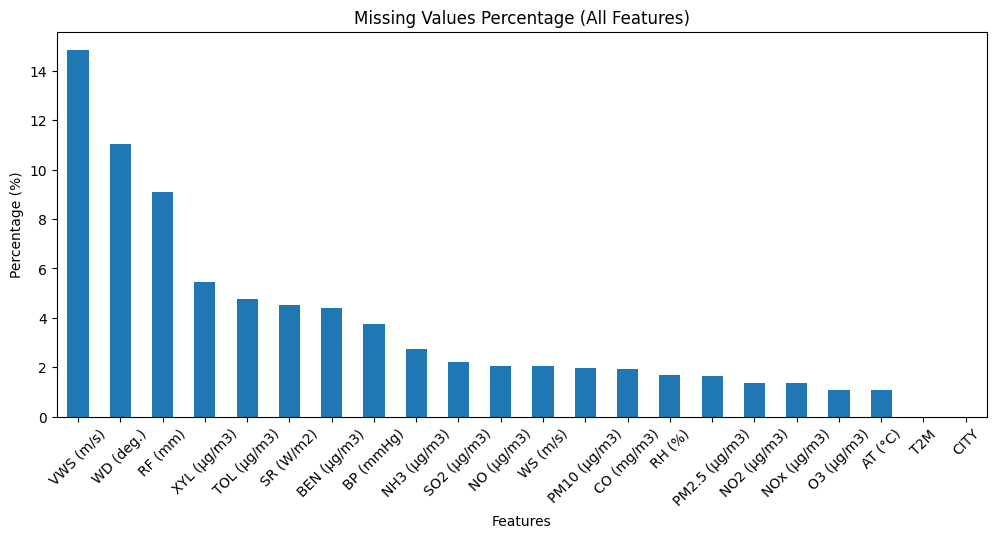

In [4]:
import matplotlib.pyplot as plt

missing.plot(kind='bar', figsize=(12,5))
plt.title("Missing Values Percentage (All Features)")
plt.ylabel("Percentage (%)")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

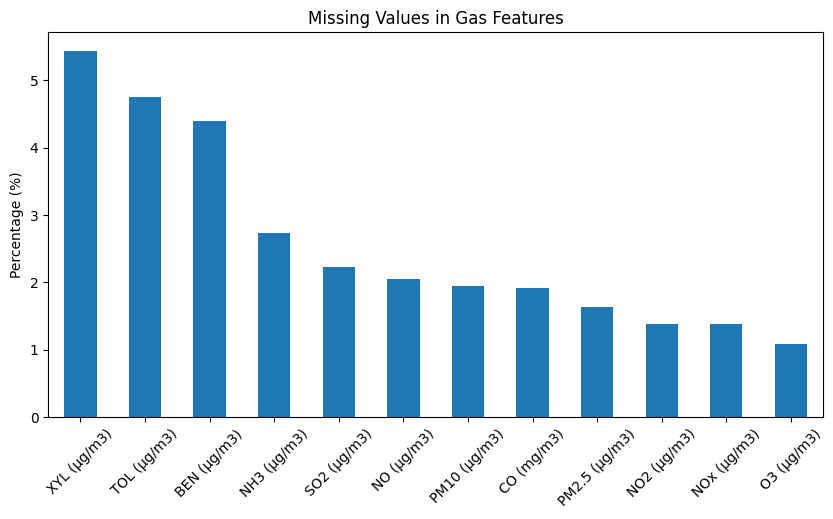

In [5]:
gas_cols = [col for col in df.columns if 'μg/m3' in col or 'mg/m3' in col]

gas_missing = df[gas_cols].isnull().mean() * 100
gas_missing = gas_missing.sort_values(ascending=False)

gas_missing.plot(kind='bar', figsize=(10,5))
plt.title("Missing Values in Gas Features")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

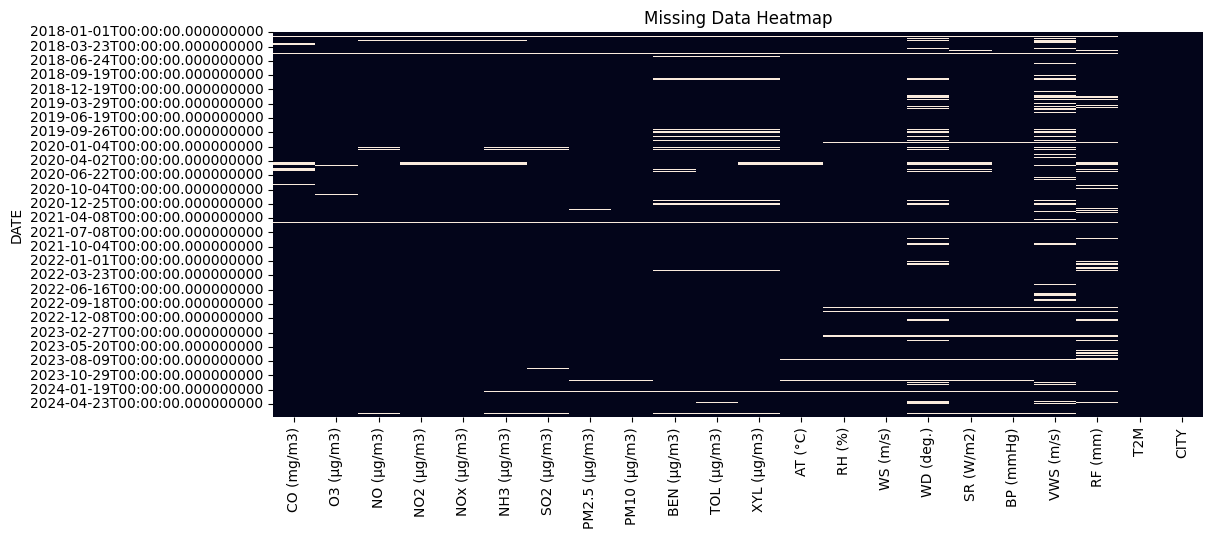

In [6]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

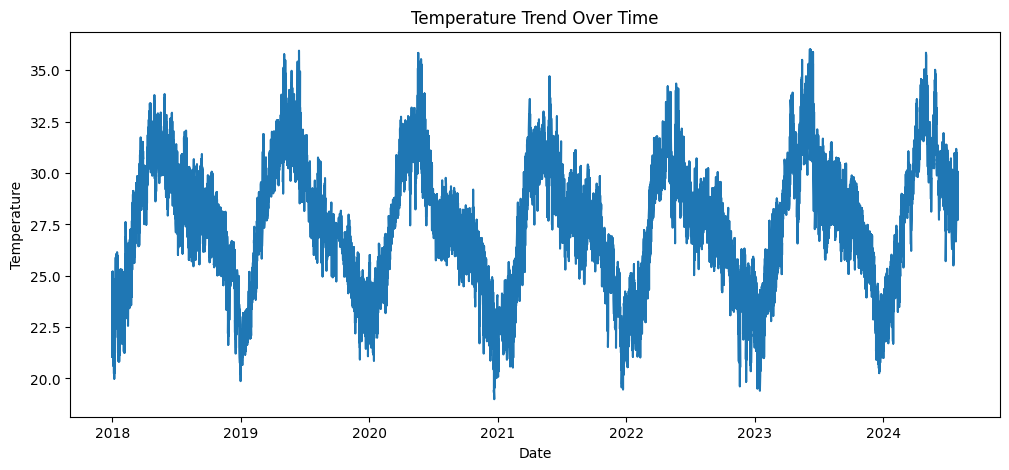

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['T2M'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

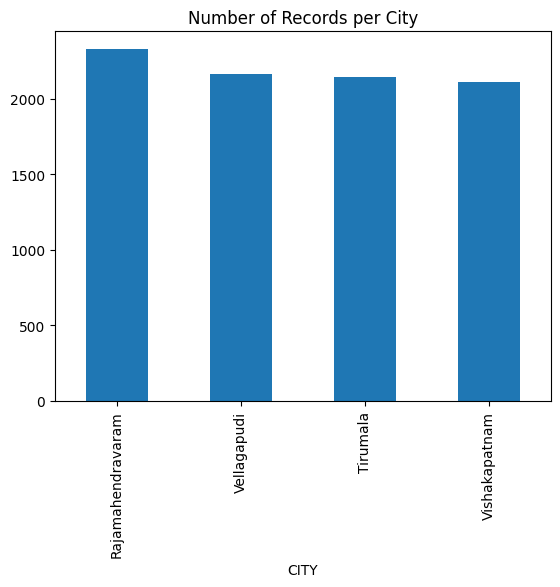

In [8]:
df['CITY'].value_counts().plot(kind='bar')
plt.title("Number of Records per City")
plt.show()

In [9]:
drop_cols = [
    'BEN (μg/m3)', 'TOL (μg/m3)', 'XYL (μg/m3)',
    'WD (deg.)', 'VWS (m/s)', 'RF (mm)'
]

df = df.drop(columns=drop_cols)

In [10]:
features = ['CITY', 'T2M', 'O3 (μg/m3)', 'NO2 (μg/m3)', 'PM2.5 (μg/m3)']
df = df[features]

In [11]:
# Separate CITY
city_col = df['CITY']

# Interpolate numeric
df_numeric = df.drop(columns=['CITY'])
df_numeric = df_numeric.interpolate(method='time')
df_numeric = df_numeric.bfill()

# Combine back
df = df_numeric.copy()
df['CITY'] = city_col

In [12]:
df.isnull().sum()

T2M              0
O3 (μg/m3)       0
NO2 (μg/m3)      0
PM2.5 (μg/m3)    0
CITY             0
dtype: int64

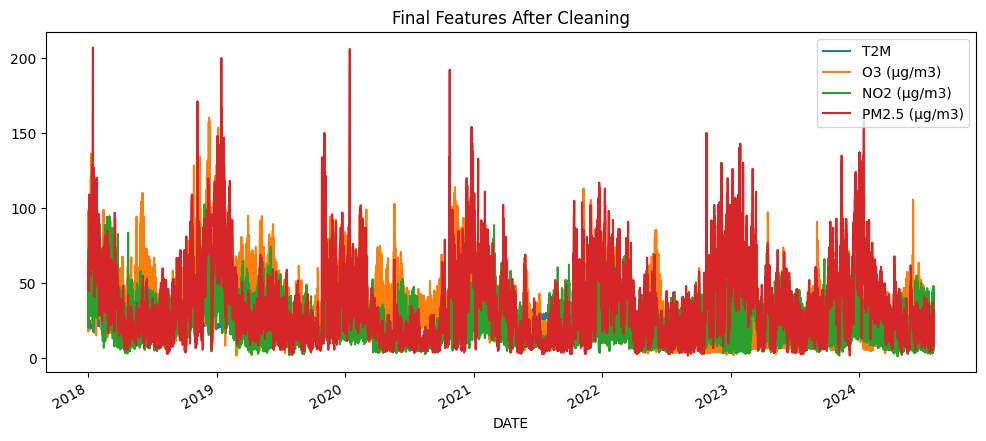

In [13]:
df.drop(columns=['CITY']).plot(figsize=(12,5))
plt.title("Final Features After Cleaning")
plt.show()

In [14]:
#cyclic encoding

In [15]:
import numpy as np

df['month'] = df.index.month
df['day'] = df.index.day

In [16]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [17]:
df = df.drop(columns=['month', 'day'])

In [18]:
df.head()

,T2M,O3 (μg/m3),NO2 (μg/m3),PM2.5 (μg/m3),CITY,month_sin,month_cos,day_sin,day_cos
DATE,,,,,,,,,
2018-01-01,22.74,97.3,24.7,59.0,Rajamahendravaram,0.5,0.866025,0.201299,0.979530
2018-01-01,21.05,95.5,22.9,58.0,Vishakapatnam,0.5,0.866025,0.201299,0.979530
2018-01-01,25.19,89.2,20.6,60.0,Vellagapudi,0.5,0.866025,0.201299,0.979530
2018-01-01,22.07,17.9,72.8,45.0,Tirumala,0.5,0.866025,0.201299,0.979530
2018-01-02,22.68,99.0,28.9,65.0,Vishakapatnam,0.5,0.866025,0.394356,0.918958


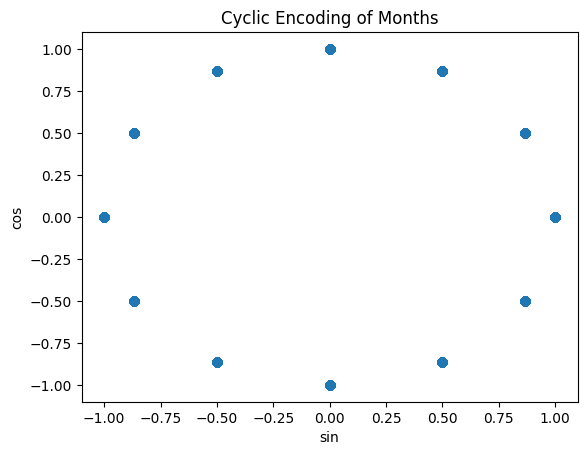

In [19]:
import matplotlib.pyplot as plt

plt.scatter(df['month_sin'], df['month_cos'], alpha=0.5)
plt.title("Cyclic Encoding of Months")
plt.xlabel("sin")
plt.ylabel("cos")
plt.show()

In [20]:
cities = df['CITY'].unique()

city_data = {}

for city in cities:
    city_df = df[df['CITY'] == city].drop(columns=['CITY'])
    city_data[city] = city_df

In [21]:
#lstm

In [22]:
from sklearn.preprocessing import MinMaxScaler

scalers = {}
scaled_data = {}

for city in cities:
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(city_data[city])

    scalers[city] = scaler
    scaled_data[city] = scaled

In [23]:
#Create Sequences
import numpy as np

def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # T2M
    return np.array(X), np.array(y)

In [24]:
#Train/Test Split (Time-based)
X_data = {}
y_data = {}

for city in cities:
    X, y = create_sequences(scaled_data[city])

    split = int(0.8 * len(X))

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    X_data[city] = (X_train, X_test)
    y_data[city] = (y_train, y_test)

In [25]:
#Build LSTM

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

models = {}

for city in cities:
    X_train, X_test = X_data[city]
    y_train, y_test = y_data[city]

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    print(f"Training LSTM for {city}...")
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    models[city] = model

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for Rajamahendravaram...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0238
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0043
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0039
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0039
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0037
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0036
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0035
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0033
Epoch 9/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0032
Epoch 10/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0032
Training LSTM for Vishakapatnam...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0254
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0046
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0043
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0041


In [27]:
#random forest to compare

In [28]:
df_rf = df.copy()

for lag in range(1, 8):
    df_rf[f'T2M_lag_{lag}'] = df_rf.groupby('CITY')['T2M'].shift(lag)

df_rf = df_rf.dropna()

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf_models = {}

for city in df_rf['CITY'].unique():
    city_df = df_rf[df_rf['CITY'] == city]

    X = city_df.drop(columns=['CITY', 'T2M'])
    y = city_df['T2M']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestRegressor(n_estimators=100)
    model.fit(X_train, y_train)

    rf_models[city] = model

In [30]:
from sklearn.metrics import mean_squared_error

for city in cities:
    # LSTM
    X_test = X_data[city][1]
    y_test = y_data[city][1]
    lstm_pred = models[city].predict(X_test)

    lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))

    print(f"{city} - LSTM RMSE:", lstm_rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Rajamahendravaram - LSTM RMSE: 0.08028695771783101
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Vishakapatnam - LSTM RMSE: 0.060754413515877
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
Vellagapudi - LSTM RMSE: 0.07379422054339511
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Tirumala - LSTM RMSE: 0.07434581998212662


In [31]:
#LSTM Evaluation Metrics

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\nCity: {city}")
    print("LSTM RMSE:", rmse)
    print("LSTM MAE:", mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

City: Rajamahendravaram
LSTM RMSE: 0.08028695771783101
LSTM MAE: 0.059783344589596485
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

City: Vishakapatnam
LSTM RMSE: 0.060754413515877
LSTM MAE: 0.04604351244496856
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

City: Vellagapudi
LSTM RMSE: 0.07379422054339511
LSTM MAE: 0.05706095289240521
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

City: Tirumala
LSTM RMSE: 0.07434581998212662
LSTM MAE: 0.057521594391502215


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


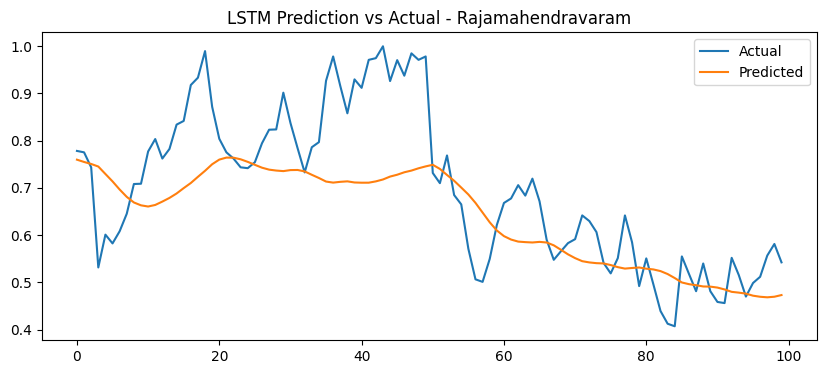

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


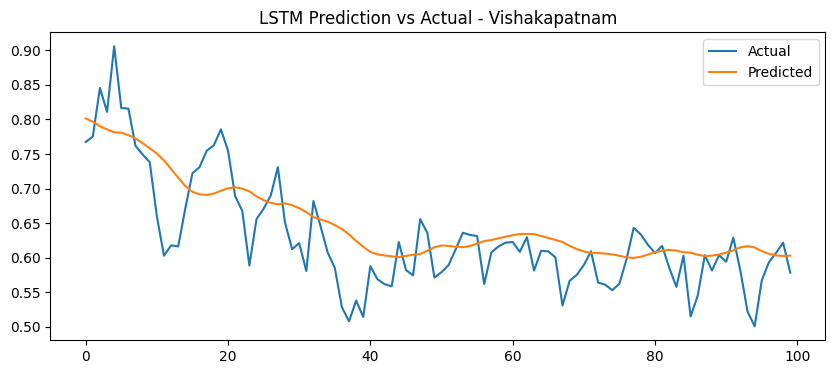

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


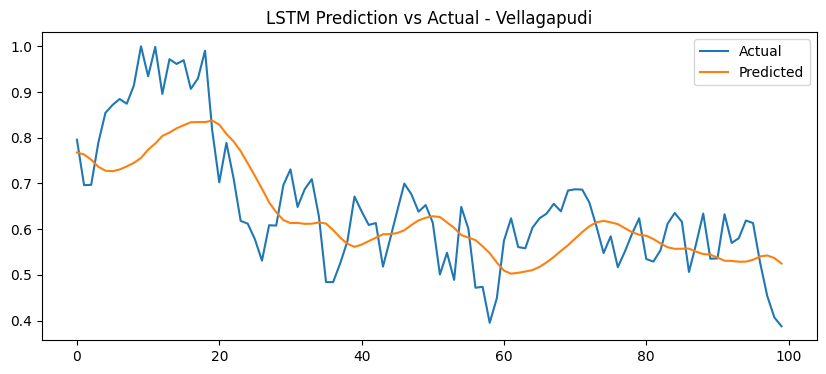

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


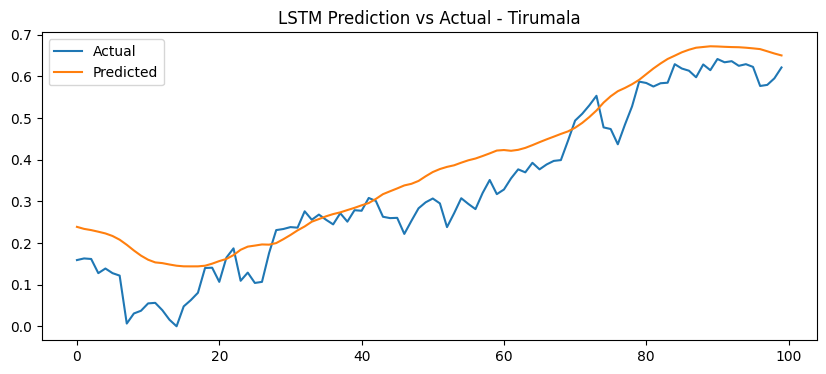

In [33]:
import matplotlib.pyplot as plt

for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    plt.figure(figsize=(10,4))
    plt.plot(y_test[:100], label='Actual')
    plt.plot(y_pred[:100], label='Predicted')
    plt.title(f"LSTM Prediction vs Actual - {city}")
    plt.legend()
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


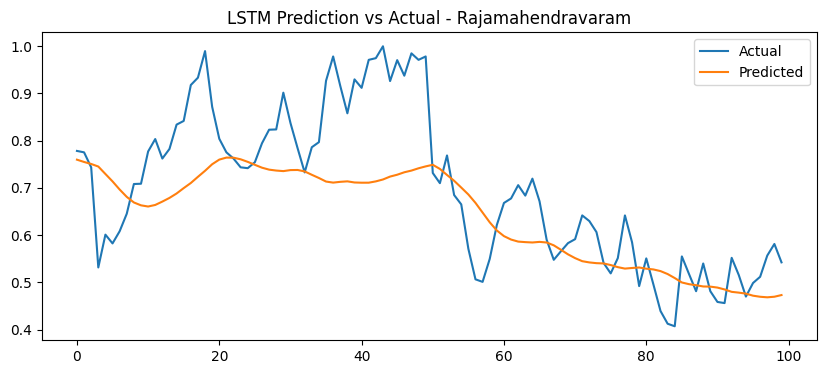

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


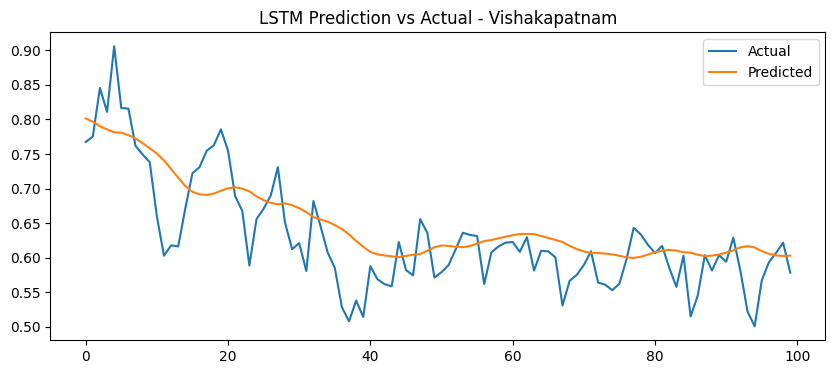

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


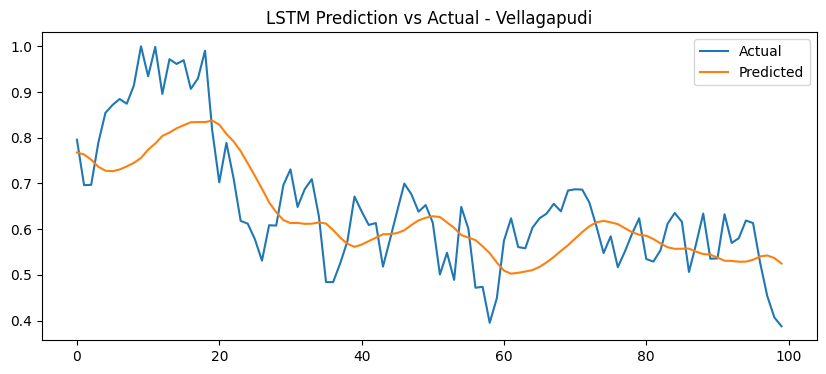

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


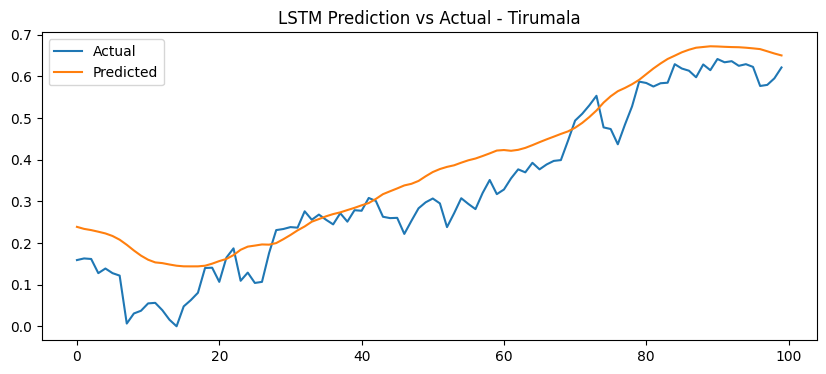

In [34]:
import matplotlib.pyplot as plt

for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    plt.figure(figsize=(10,4))
    plt.plot(y_test[:100], label='Actual')
    plt.plot(y_pred[:100], label='Predicted')
    plt.title(f"LSTM Prediction vs Actual - {city}")
    plt.legend()
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


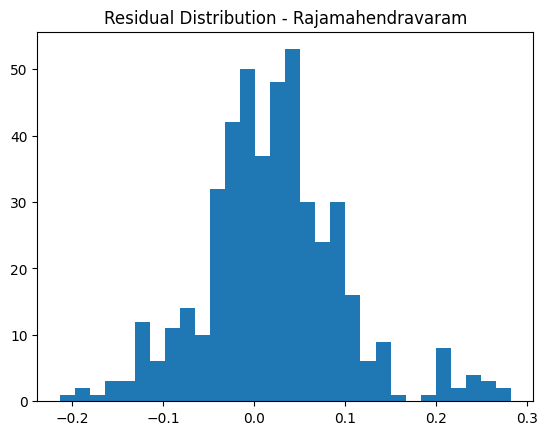

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


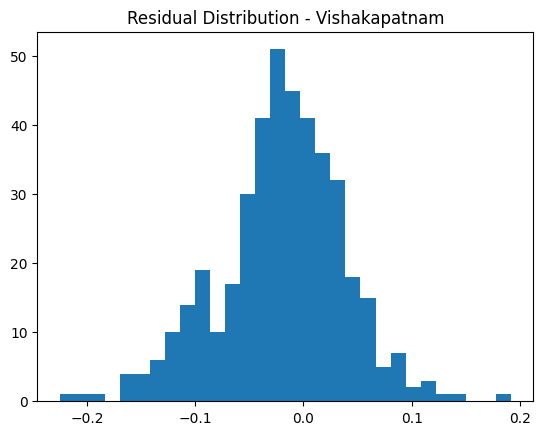

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


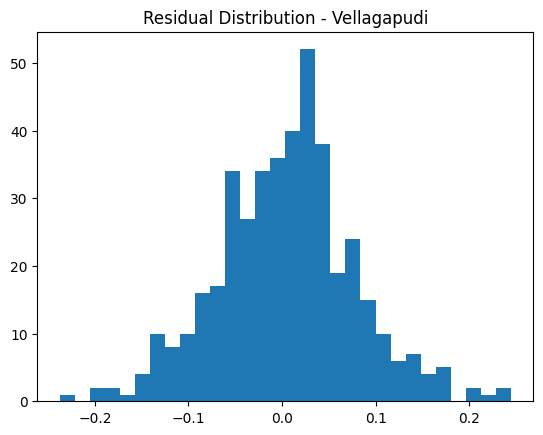

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


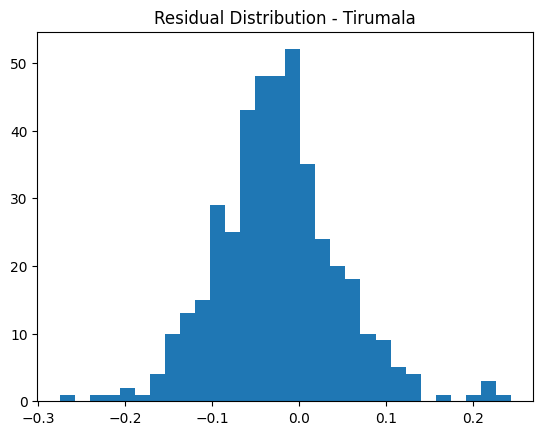

In [35]:
for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    residuals = y_test - y_pred.flatten()

    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title(f"Residual Distribution - {city}")
    plt.show()

In [36]:
#prediction

In [37]:
def predict_temperature_fixed(city, target_date, seq_length=30):

    city = city.strip()

    if city not in models:
        return f"City not found. Available: {list(models.keys())}"

    model = models[city]
    scaler = scalers[city]
    data = city_data[city].copy()

    last_date = data.index[-1]
    target_date = pd.to_datetime(target_date)

    days_ahead = (target_date - last_date).days

    if days_ahead <= 0:
        return "Enter a future date"

    # Prepare sequence
    scaled_data = scaler.transform(data)
    current_seq = scaled_data[-seq_length:]

    for _ in range(days_ahead):
        pred = model.predict(current_seq.reshape(1, seq_length, -1), verbose=0)

        # update sequence
        next_row = current_seq[-1].copy()
        next_row[0] = pred[0][0]
        current_seq = np.vstack([current_seq[1:], next_row])

    # 🔥 FIX HERE: inverse scaling
    dummy = np.zeros((1, current_seq.shape[1]))
    dummy[0][0] = pred[0][0]

    temp_real = scaler.inverse_transform(dummy)[0][0]

    return round(float(temp_real), 2)

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("🔹 LSTM MODEL EVALUATION")
print("="*40)

lstm_results = {}

for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    lstm_results[city] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\nCity: {city}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

🔹 LSTM MODEL EVALUATION
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

City: Rajamahendravaram
RMSE: 0.0803
MAE : 0.0598
R²  : 0.8403
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

City: Vishakapatnam
RMSE: 0.0608
MAE : 0.0460
R²  : 0.9072
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

City: Vellagapudi
RMSE: 0.0738
MAE : 0.0571
R²  : 0.8479
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

City: Tirumala
RMSE: 0.0743
MAE : 0.0575
R²  : 0.8843


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("\n🔹 RANDOM FOREST EVALUATION")
print("="*40)

rf_results = {}

for city in df_rf['CITY'].unique():
    city_df = df_rf[df_rf['CITY'] == city]

    X = city_df.drop(columns=['CITY', 'T2M'])
    y = city_df['T2M']

    split = int(0.8 * len(X))

    X_test = X.iloc[split:]
    y_test = y.iloc[split:]

    model = rf_models[city]
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    rf_results[city] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\nCity: {city}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")


🔹 RANDOM FOREST EVALUATION

City: Vishakapatnam
RMSE: 0.5489
MAE : 0.4154
R²  : 0.9535

City: Tirumala
RMSE: 0.7304
MAE : 0.5581
R²  : 0.9524

City: Vellagapudi
RMSE: 0.7712
MAE : 0.5729
R²  : 0.9226

City: Rajamahendravaram
RMSE: 0.8764
MAE : 0.6544
R²  : 0.9315


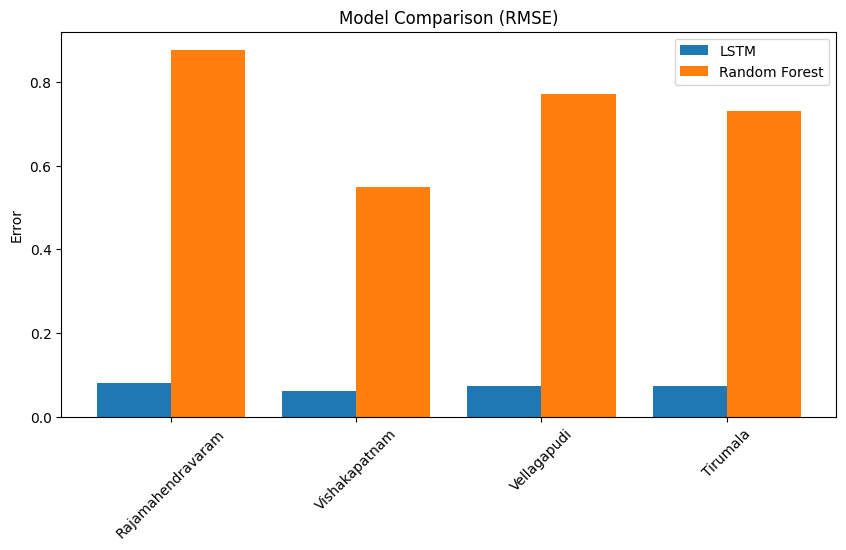

In [40]:
import matplotlib.pyplot as plt

lstm_rmse = []
rf_rmse = []

for city in cities:
    lstm_rmse.append(lstm_results[city]["RMSE"])
    rf_rmse.append(rf_results[city]["RMSE"])

x = range(len(cities))

plt.figure(figsize=(10,5))
plt.bar(x, lstm_rmse, width=0.4, label='LSTM')
plt.bar([i+0.4 for i in x], rf_rmse, width=0.4, label='Random Forest')

plt.xticks([i+0.2 for i in x], cities, rotation=45)
plt.title("Model Comparison (RMSE)")
plt.ylabel("Error")
plt.legend()
plt.show()

In [41]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for city in df_rf['CITY'].unique():
    city_df = df_rf[df_rf['CITY'] == city]

    X = city_df.drop(columns=['CITY', 'T2M'])
    y = city_df['T2M']

    scores = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestRegressor(n_estimators=100)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        scores.append(rmse)

    print(f"\nCity: {city}")
    print("TimeSeries CV RMSE:", scores)
    print("Average RMSE:", np.mean(scores))


City: Vishakapatnam
TimeSeries CV RMSE: [np.float64(0.5690461107100951), np.float64(0.5427656796971811), np.float64(0.49489397785211087), np.float64(0.5025838544959437), np.float64(0.5405886306874862)]
Average RMSE: 0.5299756506885634

City: Tirumala
TimeSeries CV RMSE: [np.float64(0.7967413017826362), np.float64(0.7617678680933916), np.float64(0.6935758582937174), np.float64(0.7553756035906899), np.float64(0.7274845842028598)]
Average RMSE: 0.746989043192659

City: Vellagapudi
TimeSeries CV RMSE: [np.float64(1.050124279791849), np.float64(0.7202480409756394), np.float64(0.7052062686455979), np.float64(0.711003460005137), np.float64(0.712453649061665)]
Average RMSE: 0.7798071396959776

City: Rajamahendravaram
TimeSeries CV RMSE: [np.float64(0.8594326376490049), np.float64(0.7236934895710667), np.float64(0.686958909324842), np.float64(0.8574179489299772), np.float64(0.6924626267958758)]
Average RMSE: 0.7639931224541533


In [42]:
from sklearn.metrics import r2_score
import numpy as np

lstm_r2_scores = []

for city in cities:
    X_test = X_data[city][1]
    y_test = y_data[city][1]

    y_pred = models[city].predict(X_test)

    r2 = r2_score(y_test, y_pred)
    lstm_r2_scores.append(r2)

# Final accuracy
final_lstm_accuracy = np.mean(lstm_r2_scores)

print("✅ Final LSTM Accuracy (R²):", round(final_lstm_accuracy, 4))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
✅ Final LSTM Accuracy (R²): 0.8699


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


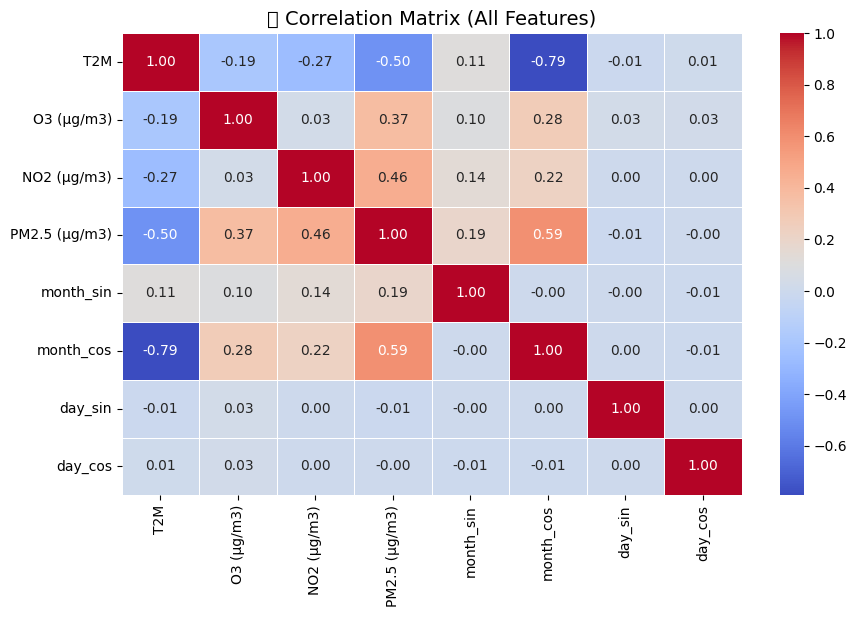

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop CITY (non-numeric)
corr_df = df.drop(columns=['CITY'])

# Correlation matrix
corr_matrix = corr_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("🌡 Correlation Matrix (All Features)", fontsize=14)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29268\7244441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp_corr.values, y=temp_corr.index, palette='viridis')
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


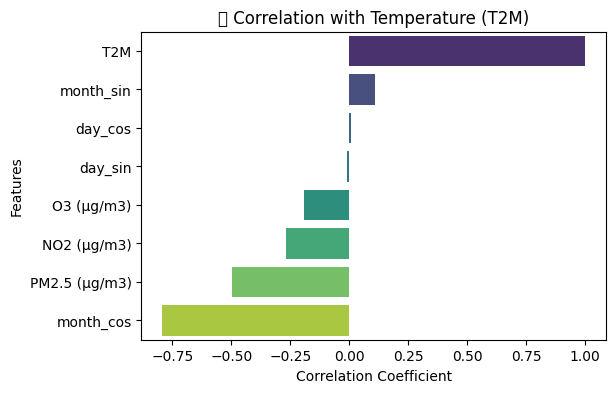

In [44]:
temp_corr = corr_matrix['T2M'].sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=temp_corr.values, y=temp_corr.index, palette='viridis')

plt.title("🔥 Correlation with Temperature (T2M)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


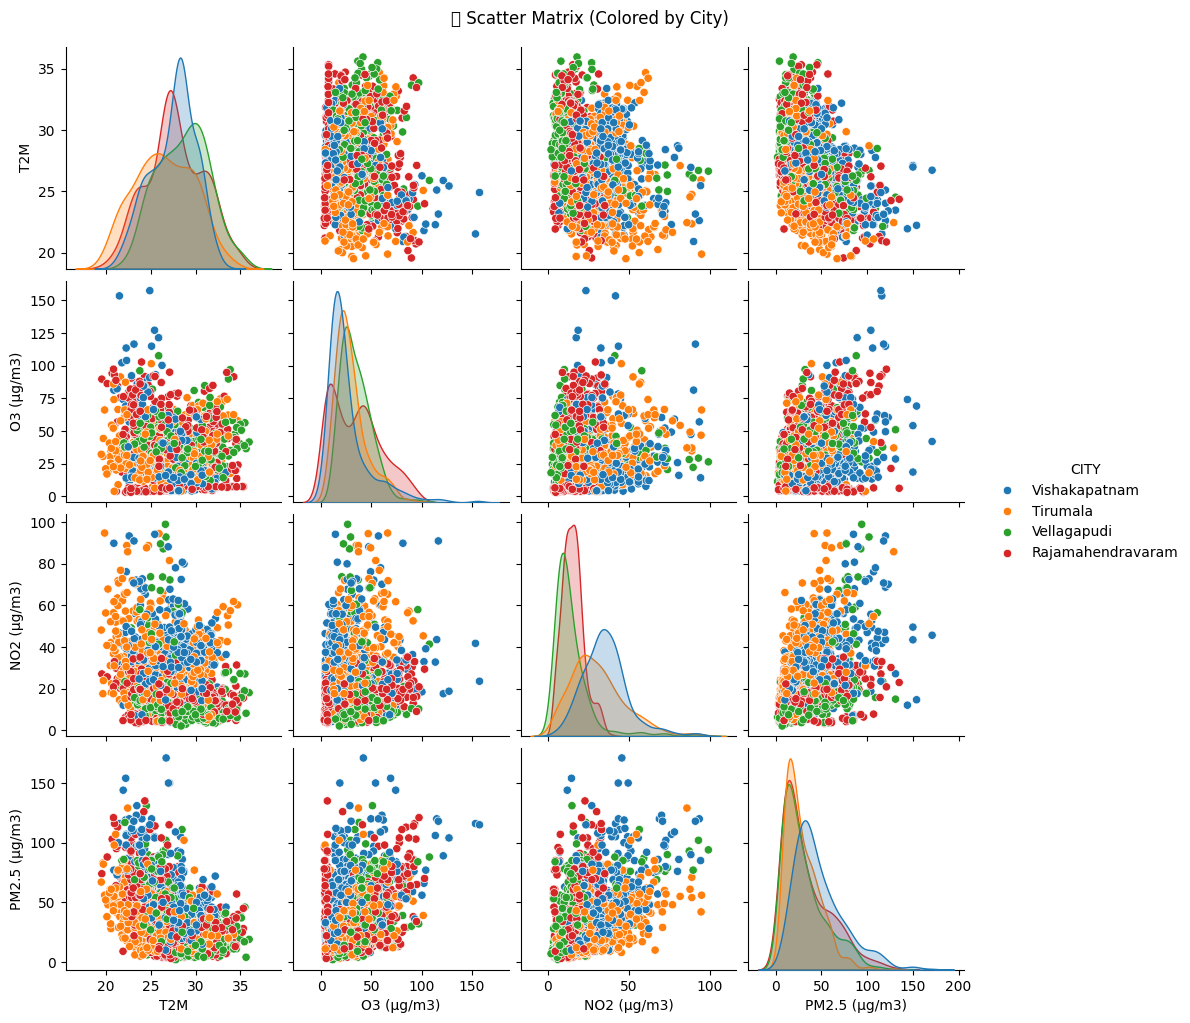

In [45]:
import pandas as pd

# Sample data (to avoid clutter if dataset is large)
sample_df = df.sample(2000) if len(df) > 2000 else df

# Scatter matrix
sns.pairplot(
    sample_df,
    vars=['T2M', 'O3 (μg/m3)', 'NO2 (μg/m3)', 'PM2.5 (μg/m3)'],
    hue='CITY',
    palette='tab10',
    diag_kind='kde'
)

plt.suptitle("🌈 Scatter Matrix (Colored by City)", y=1.02)
plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


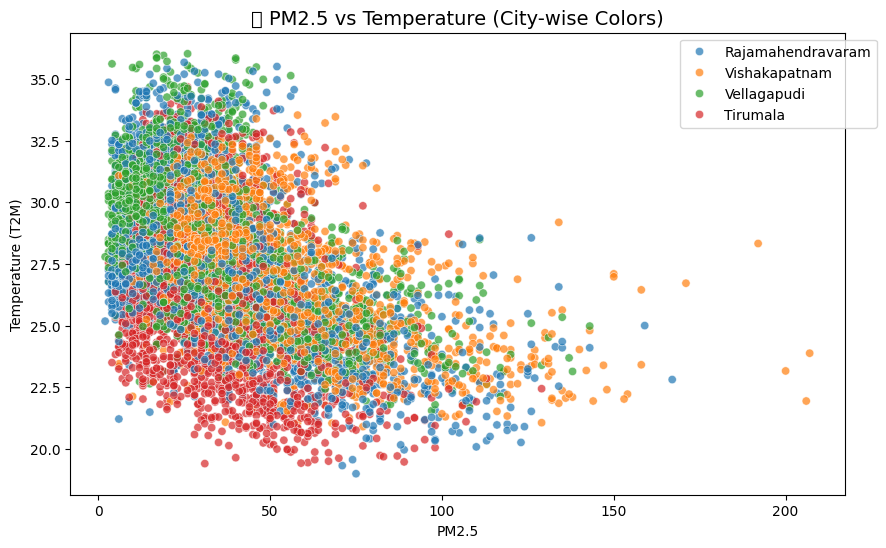

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PM2.5 (μg/m3)',
    y='T2M',
    hue='CITY',
    palette='tab10',
    alpha=0.7
)

plt.title("🌫 PM2.5 vs Temperature (City-wise Colors)", fontsize=14)
plt.xlabel("PM2.5")
plt.ylabel("Temperature (T2M)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


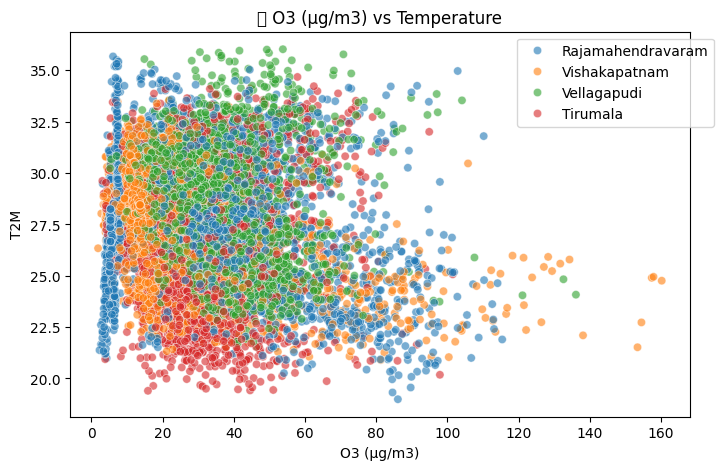

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


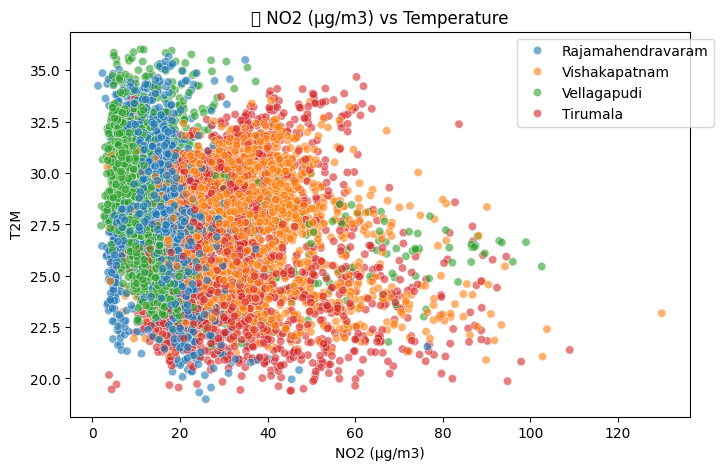

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


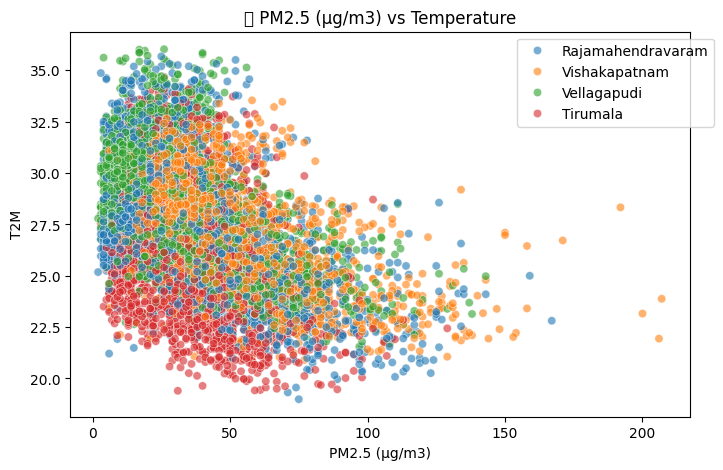

In [47]:
features = ['O3 (μg/m3)', 'NO2 (μg/m3)', 'PM2.5 (μg/m3)']

for feature in features:
    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=feature,
        y='T2M',
        hue='CITY',
        palette='tab10',
        alpha=0.6
    )

    plt.title(f"🌈 {feature} vs Temperature")
    plt.xlabel(feature)
    plt.ylabel("T2M")
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.show()

In [48]:
from sklearn.metrics import r2_score
import numpy as np

rf_r2_scores = []

for city in df_rf['CITY'].unique():
    city_df = df_rf[df_rf['CITY'] == city]

    X = city_df.drop(columns=['CITY', 'T2M'])
    y = city_df['T2M']

    split = int(0.8 * len(X))

    X_test = X.iloc[split:]
    y_test = y.iloc[split:]

    y_pred = rf_models[city].predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rf_r2_scores.append(r2)

# Final accuracy
final_rf_accuracy = np.mean(rf_r2_scores)

print("✅ Final Random Forest Accuracy (R²):", round(final_rf_accuracy, 4))

✅ Final Random Forest Accuracy (R²): 0.94


In [49]:
!pip install ipywidgets

import ipywidgets as widgets
from IPython.display import display
from datetime import datetime

     -------------------------------------- 139.8/139.8 kB 2.8 MB/s eta 0:00:00
  Using cached comm-0.2.3-py3-none-any.whl (7.3 kB)
     -------------------------------------- 622.8/622.8 kB 3.0 MB/s eta 0:00:00
  Using cached traitlets-5.14.3-py3-none-any.whl (85 kB)
     ---------------------------------------- 2.2/2.2 MB 3.9 MB/s eta 0:00:00
     -------------------------------------- 914.9/914.9 kB 2.8 MB/s eta 0:00:00
  Using cached decorator-5.2.1-py3-none-any.whl (9.2 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl (1.6 MB)
  Using cached matplotlib_inline-0.2.1-py3-none-any.whl (9.5 kB)
  Using cached prompt_toolkit-3.0.52-py3-none-any.whl (391 kB)
  Using cached stack_data-0.6.3-py3-none-any.whl (24 kB)
     -------------------------------------- 106.9/106.9 kB 3.0 MB/s eta 0:00:00
  Using cached wcwidth-0.6.0-py3-none-any.whl (94 kB)
  Using cached executing-2.2.1-py2.py3-none-any.whl (28 kB)
  Using cached asttokens-3.0.1-py3-none-any.whl (27 kB)
  Using cached pure_eval


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [ ]:
# City dropdown
city_dropdown = widgets.Dropdown(
    options=sorted(list(models.keys())),
    description='City:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Date picker
date_picker = widgets.DatePicker(
    description='Select Date:',
    disabled=False
)

# Button
predict_button = widgets.Button(
    description="Predict Temperature",
    button_style='success'
)

# Output display
output = widgets.Output()

In [51]:
def on_predict_clicked(b):
    output.clear_output()

    city = city_dropdown.value
    selected_date = date_picker.value

    with output:
        if selected_date is None:
            print("⚠️ Please select a date")
            return

        target_date = selected_date.strftime('%Y-%m-%d')

        result = predict_temperature_fixed(city, target_date)

        print(f"📍 City: {city}")
        print(f"📅 Date: {target_date}")
        print(f"🌡 Predicted Temperature: {result} °C")

predict_button.on_click(on_predict_clicked)

In [52]:
display(city_dropdown, date_picker, predict_button, output)

Dropdown(description='City:', layout=Layout(width='300px'), options=('Rajamahendravaram', 'Tirumala', 'Vellaga…

DatePicker(value=None, description='Select Date:', step=1)

Button(button_style='success', description='Predict Temperature', style=ButtonStyle())

Output()

In [53]:
print("=" * 80)
print("📊 COMPREHENSIVE MODEL METRICS SUMMARY")
print("=" * 80)

print("\n🔹 LSTM MODEL METRICS:")
print("-" * 80)
for city in lstm_results:
    print(f"\n{city}:")
    print(f"  RMSE: {lstm_results[city]['RMSE']:.4f}")
    print(f"  MAE:  {lstm_results[city]['MAE']:.4f}")
    print(f"  R²:   {lstm_results[city]['R2']:.4f}")
print(f"\nOverall LSTM Accuracy (R²): {final_lstm_accuracy:.4f}")

print("\n" + "=" * 80)
print("\n🔹 RANDOM FOREST MODEL METRICS:")
print("-" * 80)
for city in rf_results:
    print(f"\n{city}:")
    print(f"  RMSE: {rf_results[city]['RMSE']:.4f}")
    print(f"  MAE:  {rf_results[city]['MAE']:.4f}")
    print(f"  R²:   {rf_results[city]['R2']:.4f}")
print(f"\nOverall Random Forest Accuracy (R²): {final_rf_accuracy:.4f}")

print("\n" + "=" * 80)
print("\n📈 MODEL COMPARISON:")
print("-" * 80)
comparison_df = pd.DataFrame({
    'Metric': ['Overall R² Score', 'Avg RMSE', 'Avg MAE'],
    'LSTM': [
        f"{final_lstm_accuracy:.4f}",
        f"{np.mean(lstm_rmse):.4f}",
        f"{np.mean([lstm_results[c]['MAE'] for c in lstm_results]):.4f}"
    ],
    'Random Forest': [
        f"{final_rf_accuracy:.4f}",
        f"{np.mean(rf_rmse):.4f}",
        f"{np.mean([rf_results[c]['MAE'] for c in rf_results]):.4f}"
    ]
})
print(comparison_df.to_string(index=False))
print("\n" + "=" * 80)

📊 COMPREHENSIVE MODEL METRICS SUMMARY

🔹 LSTM MODEL METRICS:
--------------------------------------------------------------------------------

Rajamahendravaram:
  RMSE: 0.0803
  MAE:  0.0598
  R²:   0.8403

Vishakapatnam:
  RMSE: 0.0608
  MAE:  0.0460
  R²:   0.9072

Vellagapudi:
  RMSE: 0.0738
  MAE:  0.0571
  R²:   0.8479

Tirumala:
  RMSE: 0.0743
  MAE:  0.0575
  R²:   0.8843

Overall LSTM Accuracy (R²): 0.8699


🔹 RANDOM FOREST MODEL METRICS:
--------------------------------------------------------------------------------

Vishakapatnam:
  RMSE: 0.5489
  MAE:  0.4154
  R²:   0.9535

Tirumala:
  RMSE: 0.7304
  MAE:  0.5581
  R²:   0.9524

Vellagapudi:
  RMSE: 0.7712
  MAE:  0.5729
  R²:   0.9226

Rajamahendravaram:
  RMSE: 0.8764
  MAE:  0.6544
  R²:   0.9315

Overall Random Forest Accuracy (R²): 0.9400


📈 MODEL COMPARISON:
--------------------------------------------------------------------------------
          Metric   LSTM Random Forest
Overall R² Score 0.8699        0.9400
  